In [1]:
import pandas as pd

df = pd.read_csv('chembl_for_agents.csv')
data_df = df[["canonical_smiles", "logP", "MW", "HBD", "HBA"]]
data_df.head()

,canonical_smiles,logP,MW,HBD,HBA
0,NC(=O)C1(NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@@H](Cc...,2.5882,790.991,8,8
1,O=C1CC[C@H](N2C(=O)c3cccc(NCc4ccc(CN5CC(N6CCOC...,1.3554,535.576,2,8
2,CC(C)OC(=O)C(C(=O)OC(C)C)=C1SC=CS1,3.0524,288.390,0,6
3,C[C@H]1CC(=O)C[C@@H]2CC[C@H]3[C@@H]4CC[C@H](O)...,4.2051,304.474,1,2
4,COc1c2occc2c(OC)c2c(=O)cc(CSC)oc12,3.4194,306.339,0,6


In [2]:
import torch
from torch_geometric.data import Data
from rdkit import Chem
from rdkit.Chem import Descriptors
from tqdm import tqdm


def smiles_to_graph(smiles, targets):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Atom features 
    atom_feats = []
    for atom in mol.GetAtoms():
        atom_feats.append([
            atom.GetAtomicNum(),
            atom.GetTotalDegree(),
            atom.GetFormalCharge(),
            atom.GetTotalNumHs(),
            atom.GetIsAromatic()
        ])
    atom_feats = torch.tensor(atom_feats, dtype=torch.float)

    # Bond info 
    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        a = bond.GetBeginAtomIdx()
        b = bond.GetEndAtomIdx()

        # bond features
        btype = bond.GetBondType()
        bond_feats = [
            btype == Chem.rdchem.BondType.SINGLE,
            btype == Chem.rdchem.BondType.DOUBLE,
            btype == Chem.rdchem.BondType.TRIPLE,
            btype == Chem.rdchem.BondType.AROMATIC,
            bond.GetIsConjugated(),
            bond.IsInRing(),
        ]

        # undirected edges: a<->b
        edge_index.append([a, b])
        edge_attr.append(bond_feats)

        edge_index.append([b, a])
        edge_attr.append(bond_feats)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

  
    y = torch.tensor(targets, dtype=torch.float)

    return Data(
        x=atom_feats,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y
    )

c:\Users\TYC\Desktop\python code\drug_agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_list = []

for i, row in df.iterrows():
    smiles = row["canonical_smiles"]
    targets = [row["logP"], row["MW"], row["HBD"], row["HBA"]]

    g = smiles_to_graph(smiles, targets)
    if g is not None:
        data_list.append(g)

print("Total valid molecules:", len(data_list)) 

[16:46:46] WARNING: not removing hydrogen atom without neighbors
[16:46:48] WARNING: not removing hydrogen atom without neighbors
[16:46:48] WARNING: not removing hydrogen atom without neighbors
[16:46:48] WARNING: not removing hydrogen atom without neighbors
[16:46:48] WARNING: not removing hydrogen atom without neighbors
[16:46:48] WARNING: not removing hydrogen atom without neighbors
[16:46:48] WARNING: not removing hydrogen atom without neighbors
[16:46:48] WARNING: not removing hydrogen atom without neighbors


Total valid molecules: 12761


In [4]:
from torch_geometric.loader import DataLoader

loader = DataLoader(data_list, batch_size=32, shuffle=True)

In [17]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

train_indices, temp_indices = train_test_split(
    np.arange(len(dataset)),
    test_size=0.1,
    random_state=42
)

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.5,
    random_state=42
)

train_dataset = [dataset[i] for i in train_indices]
val_dataset = [dataset[i] for i in val_indices]
test_dataset = [dataset[i] for i in test_indices]

print(f"Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

Dataset sizes: Train=11484, Val=638, Test=639


In [18]:
#set up dataloader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Example of a batch from train_loader:")
batch = next(iter(train_loader))
print(batch)
print(f"Batch node feature shape: {batch.x.shape}")

Example of a batch from train_loader:
DataBatch(x=[784, 7], edge_index=[2, 1676], edge_attr=[1676, 2], y=[32, 4], batch=[784], ptr=[33])
Batch node feature shape: torch.Size([784, 7])


In [32]:
### MODEL ARCHITECTURE ###
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool

class MultitaskGNN(nn.Module):
    def __init__ (self, num_node_features, num_edge_features, hidden_dim=64):
        super(MultitaskGNN, self).__init__()
        self.conv1 = GATv2Conv(num_node_features, hidden_dim, edge_dim=num_edge_features)
        self.conv2 = GATv2Conv(hidden_dim, hidden_dim, edge_dim=num_edge_features)
        self.conv3 = GATv2Conv(hidden_dim, hidden_dim, edge_dim=num_edge_features)

        #multi head
        self.head_logP = nn.Linear(hidden_dim, 1)
        self.head_MW = nn.Linear(hidden_dim, 1)
        self.head_HBD = nn.Linear(hidden_dim, 1)
        self.head_HBA = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.relu(self.conv3(x, edge_index, edge_attr)) 

        molecule_embedding = global_mean_pool(x, batch)

        pred_logP = self.head_logP(molecule_embedding).view(-1) 
        pred_MW = self.head_MW(molecule_embedding).view(-1)
        pred_HBD = self.head_HBD(molecule_embedding).view(-1)
        pred_HBA = self.head_HBA(molecule_embedding).view(-1)

        return torch.stack([pred_logP, pred_MW, pred_HBD, pred_HBA], dim=1) 

In [33]:
import torch.optim as optim

#feature counts
num_node_feats = dataset[0].x.shape[1]
num_edge_feats = dataset[0].edge_attr.shape[1]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultitaskGNN(num_node_feats, num_edge_feats, hidden_dim=64)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        targets = data.y
        predictions = model(data)

        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            targets = data.y
            predictions = model(data)
            loss = criterion(predictions, targets)
            total_loss += loss.item()
    return total_loss / len(loader)
        

In [35]:
#training loop
NUM_EPOCHS = 50

train_losses = []
val_losses = []
print('Device:', device)
for epoch in range(1, NUM_EPOCHS + 1):
    
    train_loss = train(model, train_loader, optimizer, criterion, device)
    val_loss = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

print('Done')


Device: cuda
Epoch: 001, Train Loss: 27678.8545, Val Loss: 34923.5537
Epoch: 002, Train Loss: 26971.8548, Val Loss: 34472.7093
Epoch: 003, Train Loss: 26592.9335, Val Loss: 34112.2065
Epoch: 004, Train Loss: 26354.1686, Val Loss: 33849.6890
Epoch: 005, Train Loss: 26305.4951, Val Loss: 34243.1731
Epoch: 006, Train Loss: 25963.0713, Val Loss: 34049.6378
Epoch: 007, Train Loss: 25555.2752, Val Loss: 34139.7550
Epoch: 008, Train Loss: 25542.7259, Val Loss: 33394.4704
Epoch: 009, Train Loss: 25518.2125, Val Loss: 33301.6107
Epoch: 010, Train Loss: 25333.5711, Val Loss: 33043.0895
Epoch: 011, Train Loss: 25204.3472, Val Loss: 33228.2312
Epoch: 012, Train Loss: 24921.2075, Val Loss: 32791.3252
Epoch: 013, Train Loss: 25228.7092, Val Loss: 32555.3994
Epoch: 014, Train Loss: 24964.2191, Val Loss: 32773.5321
Epoch: 015, Train Loss: 24989.9072, Val Loss: 32568.9346
Epoch: 016, Train Loss: 25005.6744, Val Loss: 32608.5878
Epoch: 017, Train Loss: 24722.0143, Val Loss: 32873.9318
Epoch: 018, Train 

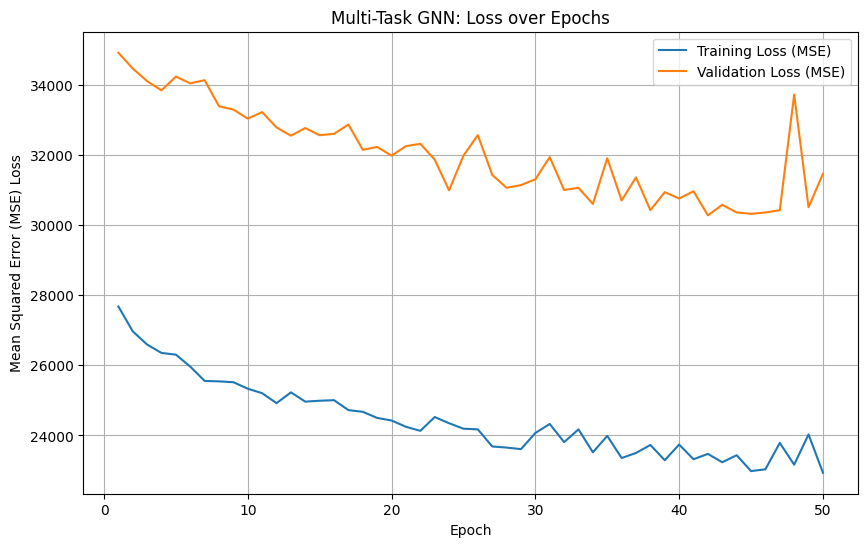

In [37]:
import matplotlib.pyplot as plt

#plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Training Loss (MSE)')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss (MSE)')
plt.title('Multi-Task GNN: Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE) Loss')
plt.legend()
plt.grid(True)
plt.show()